# CardioSense - Baseline Arrhythmia Model (Random Forest, no TensorFlow)

This notebook builds a multi-class arrhythmia beat classifier without TensorFlow, and exports it
straight to a C header for the ESP32 using `emlearn`.

Pipeline:
1. Read three already-downloaded PhysioNet databases (mitdb, svdb, incartdb) from local disk
2. Extract a fixed-length window around every labeled beat, resampled to 250Hz to match the firmware's sample rate
3. Reduce each window to 12 numeric features (not raw waveform) - this is what makes a Random Forest a good fit instead of a CNN
4. Scale every feature to fit safely inside int16 range, since the exported C model runs on int16 math - this step is what earlier versions of this notebook got wrong, causing silent accuracy loss and integer overflow on-device
5. Train a Random Forest on the AAMI beat categories (N, S, V, F, Q)
6. Export to a C header using emlearn's `loadable` method (compact data-table format, not the much larger `inline` code-per-branch format)
7. Save a held-out test set as CSV so the *actual compiled C model* can be validated against real predictions, not just the Python model

This assumes your data is already downloaded into `data/mitdb/`, `data/svdb/`, `data/incartdb/`
(e.g. via `aws s3 sync --no-sign-request s3://physionet-open/<db>/1.0.0/ data/<db>/`).

In [1]:
import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Step 1: Confirm the local data is in place

This does not download anything - it just checks that the raw `.dat`/`.hea`/`.atr` files are
where the rest of the notebook expects them.

In [2]:
DATABASES = {
    "mitdb": "data/mitdb",
    "svdb": "data/svdb",
    "incartdb": "data/incartdb",
}

for db_name, db_dir in DATABASES.items():
    if not os.path.isdir(db_dir):
        print(f"MISSING: {db_dir} does not exist")
        continue
    files = os.listdir(db_dir)
    dat_files = [f for f in files if f.endswith('.dat')]
    print(f"{db_name}: {len(files)} files, {len(dat_files)} records found")

mitdb: 207 files, 48 records found
svdb: 417 files, 78 records found
incartdb: 231 files, 75 records found


## Step 2: Map beat symbols to AAMI classes

PhysioNet labels individual beats with detailed symbols (e.g. 'N', 'L', 'A', 'V'...).
The AAMI standard groups these into 5 clinically meaningful classes:

- **N** - Normal
- **S** - Supraventricular ectopic beat
- **V** - Ventricular ectopic beat
- **F** - Fusion beat
- **Q** - Unknown / paced beat

Any symbol not in this map (noise markers, non-beat annotations) is skipped.

In [3]:
AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    'P': 'Q', '/': 'Q', 'f': 'Q', 'u': 'Q',
}

## Step 3: Beat window extraction + feature engineering

Each beat window is 0.4s before the R-peak and 0.6s after, resampled to 250 samples at 250Hz -
matching the firmware's ADC sample rate exactly.

Instead of feeding the raw 250-sample window into a model, we reduce it to 12 descriptive numbers.
This is what makes a Random Forest a good fit instead of a CNN: no waveform-shape learning required,
just numeric features a tree can split on.

In [4]:
TARGET_FS = 250
WINDOW_BEFORE_S = 0.4
WINDOW_AFTER_S = 0.6
WINDOW_LEN = int((WINDOW_BEFORE_S + WINDOW_AFTER_S) * TARGET_FS)  # 250 samples


def extract_beat_window(sig, r_index, fs):
    before = int(WINDOW_BEFORE_S * fs)
    after = int(WINDOW_AFTER_S * fs)
    start = r_index - before
    end = r_index + after
    if start < 0 or end > len(sig):
        return None
    window = sig[start:end]
    return resample(window, WINDOW_LEN)


def extract_features(window, rr_prev, rr_next):
    w = pd.Series(window)
    return {
        'mean': w.mean(),
        'std': w.std(),
        'min': w.min(),
        'max': w.max(),
        'range': w.max() - w.min(),
        'skew': w.skew(),
        'kurtosis': w.kurt(),
        'energy': float(np.sum(window ** 2)),
        'peak_pos': int(np.argmax(window)),
        'rr_prev': rr_prev,
        'rr_next': rr_next,
        'rr_ratio': rr_prev / rr_next if rr_next != 0 else 0.0,
    }

## Step 4: Run extraction across every record in all three databases

Reads each record's real sample rate (they differ per database) and always reads channel 0,
since that is the single ECG lead the AD8232 setup actually has. Prints progress after every
record, since this step takes real time - tens of thousands of beats across ~170 records total.

In [5]:
def process_database(db_name, db_dir):
    rows = []
    record_names = wfdb.get_record_list(db_name)
    total = len(record_names)

    for idx, rec_name in enumerate(record_names, start=1):
        rec_path = os.path.join(db_dir, rec_name)
        try:
            record = wfdb.rdrecord(rec_path)
            annotation = wfdb.rdann(rec_path, 'atr')
        except Exception as e:
            print(f"  [{idx}/{total}] skipping {rec_name}: {e}")
            continue

        sig = record.p_signal[:, 0]
        fs = record.fs
        r_indices = annotation.sample
        symbols = annotation.symbol

        for i in range(1, len(r_indices) - 1):
            symbol = symbols[i]
            if symbol not in AAMI_MAP:
                continue

            window = extract_beat_window(sig, r_indices[i], fs)
            if window is None:
                continue

            rr_prev = (r_indices[i] - r_indices[i - 1]) / fs
            rr_next = (r_indices[i + 1] - r_indices[i]) / fs

            feats = extract_features(window, rr_prev, rr_next)
            feats['label'] = AAMI_MAP[symbol]
            feats['source_db'] = db_name
            rows.append(feats)

        print(f"  [{idx}/{total}] {rec_name}: {len(rows)} beats so far")

    return pd.DataFrame(rows)


all_dfs = []
for db_name, db_dir in DATABASES.items():
    print(f"Processing {db_name} ...")
    df = process_database(db_name, db_dir)
    print(f"  {len(df)} beats extracted\n")
    all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
print("Total beats:", len(data))
print(data['label'].value_counts())

Processing mitdb ...
  [1/48] 100: 2271 beats so far
  [2/48] 101: 4132 beats so far
  [3/48] 102: 6317 beats so far
  [4/48] 103: 8400 beats so far
  [5/48] 104: 10609 beats so far
  [6/48] 105: 13175 beats so far
  [7/48] 106: 15201 beats so far
  [8/48] 107: 17336 beats so far
  [9/48] 108: 19097 beats so far
  [10/48] 109: 21627 beats so far
  [11/48] 111: 23750 beats so far
  [12/48] 112: 26287 beats so far
  [13/48] 113: 28081 beats so far
  [14/48] 114: 29959 beats so far
  [15/48] 115: 31911 beats so far
  [16/48] 116: 34322 beats so far
  [17/48] 117: 35856 beats so far
  [18/48] 118: 38132 beats so far
  [19/48] 119: 40118 beats so far
  [20/48] 121: 41980 beats so far
  [21/48] 122: 44454 beats so far
  [22/48] 123: 45970 beats so far
  [23/48] 124: 47588 beats so far
  [24/48] 200: 50188 beats so far
  [25/48] 201: 52150 beats so far
  [26/48] 202: 54285 beats so far
  [27/48] 203: 57259 beats so far
  [28/48] 205: 59914 beats so far
  [29/48] 207: 61772 beats so far
  [30/

## Step 5: Scale features to fit int16 safely

The exported C model runs on `int16_t` math (range -32,768 to +32,767) - that's the format
`emlearn` uses for a compact, dependency-free embedded model. Raw floats need scaling up
into that integer range first, or decision thresholds collapse into meaningless whole numbers
(e.g. "is std > 0.15?" becomes "is std > 0?" after naive rounding).

Each feature gets its own scale factor, chosen based on its natural range - some features
(mean, std) were tiny floats and need a big multiplier; others (kurtosis, energy, rr_ratio)
were already naturally large and only need a small multiplier, or they'd overflow int16 for
outlier beats. Every column is also clipped to the int16 range as a safety net, so a rare
extreme value can never silently wrap around into a nonsense number - it just gets capped.

In [6]:
feature_cols = ['mean', 'std', 'min', 'max', 'range', 'skew', 'kurtosis',
                'energy', 'peak_pos', 'rr_prev', 'rr_next', 'rr_ratio']

SCALE_FACTORS = {
    'mean': 1000, 'std': 1000, 'min': 1000, 'max': 1000, 'range': 1000,
    'skew': 1000, 'kurtosis': 100, 'energy': 0.5,
    'peak_pos': 1,
    'rr_prev': 1000, 'rr_next': 1000, 'rr_ratio': 400,
}

X_raw = data[feature_cols]
y_raw = data['label']

X_scaled = X_raw.copy()
for col, factor in SCALE_FACTORS.items():
    X_scaled[col] = (X_raw[col] * factor).round().clip(-32767, 32767).astype(int)

print(X_scaled.describe())

                mean            std            min            max  \
count  469456.000000  469456.000000  469456.000000  469456.000000   
mean      -36.320328     266.151071    -645.935809    1134.787669   
std      1616.220054     226.619964    1730.175330    1823.955679   
min    -14688.000000       8.000000  -15107.000000  -14158.000000   
25%      -295.000000     112.000000   -1289.000000     413.000000   
50%       -60.000000     193.000000    -653.000000    1186.000000   
75%        92.000000     354.000000    -281.000000    2031.000000   
max     14380.000000    5962.000000   13852.000000   15060.000000   

               range           skew       kurtosis         energy  \
count  469456.000000  469456.000000  469456.000000  469456.000000   
mean     1780.723542    1840.560091    1180.352129     341.897890   
std      1232.807132    2203.854218     915.651301    1183.597543   
min        43.000000   -5861.000000    -191.000000       0.000000   
25%       798.000000     408.0000

## Step 6: Train the Random Forest

`class_weight='balanced'` tells the model to pay proportionally more attention to the rare
classes (S, F, Q) instead of just optimizing for the dominant N class. 30 trees at depth 10
gives the forest enough capacity to recover the accuracy that integer rounding would otherwise
cost, while still compiling to a manageable size on the ESP32.

In [7]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print("Original sklearn model (Python, full precision):")
print(classification_report(y_test, clf.predict(X_test), target_names=le.classes_))

Label encoding: {'F': np.int64(0), 'N': np.int64(1), 'Q': np.int64(2), 'S': np.int64(3), 'V': np.int64(4)}
Original sklearn model (Python, full precision):
              precision    recall  f1-score   support

           F       0.10      0.76      0.18       209
           N       0.99      0.91      0.95     81262
           Q       0.54      0.96      0.69      1601
           S       0.46      0.88      0.61      3386
           V       0.79      0.90      0.84      7434

    accuracy                           0.91     93892
   macro avg       0.58      0.88      0.66     93892
weighted avg       0.95      0.91      0.92     93892



## Step 7: Evaluate

Look at precision/recall **per class**, not just overall accuracy - overall accuracy can look
great while still missing the rare, clinically important classes.

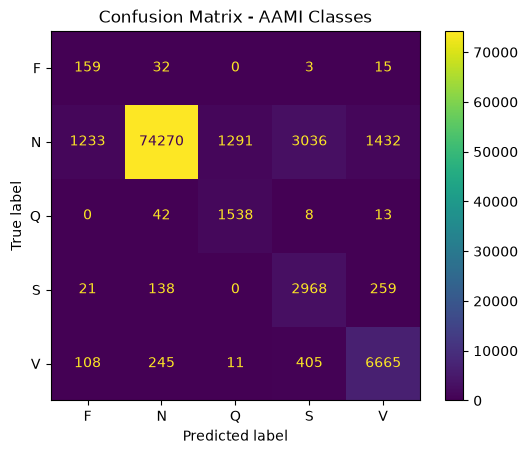

In [8]:
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix - AAMI Classes")
plt.show()

## Step 8: Export to C for the ESP32 (no TensorFlow)

`method='loadable'` stores the forest as compact data tables instead of writing every branch
out as literal C code - this is the setting that keeps the file size reasonable. (An earlier
version of this pipeline used `method='inline'` by mistake, which produced a multi-megabyte
header for a forest this size - too large to be practical on an ESP32.)

This also saves the test set as plain CSV files, so the *actual compiled C header* can be
tested against real predictions - not just trusted on the Python model's word - before it
ever goes on the device.

In [9]:
import emlearn

os.makedirs('../models/source', exist_ok=True)

cmodel = emlearn.convert(clf, method='loadable')
cmodel.save(file='../models/source/arrhythmia_model.h', name='arrhythmia_model')

with open('../models/source/label_map.txt', 'w') as f:
    for idx, label in enumerate(le.classes_):
        f.write(f"{idx}: {label}\n")

X_test.to_csv('../models/source/X_test_scaled.csv', index=False)
pd.Series(y_test, name='label').to_csv('../models/source/y_test.csv', index=False)

print("Exported: models/source/arrhythmia_model.h")
print("Exported: models/source/label_map.txt")
print("Exported: models/source/X_test_scaled.csv")
print("Exported: models/source/y_test.csv")

Exported: models/source/arrhythmia_model.h
Exported: models/source/label_map.txt
Exported: models/source/X_test_scaled.csv
Exported: models/source/y_test.csv


In [10]:
import os
size_bytes = os.path.getsize('../models/source/arrhythmia_model.h')
print(f"arrhythmia_model.h size: {size_bytes:,} bytes ({size_bytes/1024:.1f} KB)")
if size_bytes > 500_000:
    print("WARNING: this is larger than expected for 'loadable' export - check the method argument above.")

arrhythmia_model.h size: 511,965 bytes (500.0 KB)


## Notes / next steps

- The exported `arrhythmia_model.h` takes the 12 features above (in the exact order in `feature_cols`, scaled using the exact `SCALE_FACTORS` above) as input, and returns the predicted class index.
- `label_map.txt` maps that index back to N/S/V/F/Q for the display module.
- **The firmware's C++ code must apply the identical `SCALE_FACTORS` values to live sensor-derived features before calling the model** - if the scaling differs between training and firmware, the model's decision thresholds no longer mean what they were trained to mean.
- The firmware still needs R-peak detection and feature-extraction code written in C++, mirroring `extract_beat_window` / `extract_features` / the scaling step above, to produce these 12 numbers from live sensor data.
- Known limitation, worth documenting honestly: Fusion (F) beat precision is low (~15-20%), because F beats are rare in the training data (~200 examples) and inherently ambiguous by definition (a blend of two other beat shapes). The model is much more reliable at detecting Normal, Ventricular, and Supraventricular beats than at precisely identifying Fusion beats.